# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [45]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [46]:
base.head(10)

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0
5,60,1,151,67,2,2,0,0,0,0
6,61,1,157,93,3,1,0,0,1,0
7,62,2,178,95,3,3,0,0,1,1
8,48,1,158,71,1,1,0,0,1,0
9,54,1,164,68,1,1,0,0,0,0


In [47]:
base.drop_duplicates(inplace=True)

In [48]:
base.duplicated().sum()

np.int64(0)

In [49]:
base.isnull().sum()

age               0
gender            0
height            0
weight            0
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
cardio_disease    0
dtype: int64

In [50]:
base.info()

<class 'pandas.DataFrame'>
Index: 9640 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             9640 non-null   int64
 1   gender          9640 non-null   int64
 2   height          9640 non-null   int64
 3   weight          9640 non-null   str  
 4   cholesterol     9640 non-null   int64
 5   gluc            9640 non-null   int64
 6   smoke           9640 non-null   int64
 7   alco            9640 non-null   int64
 8   active          9640 non-null   int64
 9   cardio_disease  9640 non-null   int64
dtypes: int64(9), str(1)
memory usage: 828.4 KB


In [61]:
base['weight'] = (
    base['weight']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [63]:
base.info()

<class 'pandas.DataFrame'>
Index: 9640 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             9640 non-null   int64   
 1   gender          9640 non-null   int64   
 2   height          9640 non-null   int64   
 3   weight          9640 non-null   float64 
 4   cholesterol     9640 non-null   int64   
 5   gluc            9640 non-null   int64   
 6   smoke           9640 non-null   int64   
 7   alco            9640 non-null   int64   
 8   active          9640 non-null   int64   
 9   cardio_disease  9640 non-null   int64   
 10  faixa_idade     9640 non-null   category
dtypes: category(1), float64(1), int64(9)
memory usage: 838.1 KB


In [64]:
base.info()

<class 'pandas.DataFrame'>
Index: 9640 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             9640 non-null   int64   
 1   gender          9640 non-null   int64   
 2   height          9640 non-null   int64   
 3   weight          9640 non-null   float64 
 4   cholesterol     9640 non-null   int64   
 5   gluc            9640 non-null   int64   
 6   smoke           9640 non-null   int64   
 7   alco            9640 non-null   int64   
 8   active          9640 non-null   int64   
 9   cardio_disease  9640 non-null   int64   
 10  faixa_idade     9640 non-null   category
dtypes: category(1), float64(1), int64(9)
memory usage: 838.1 KB


In [52]:
base[(base['age'] > 100) | (base['age'] < 1)]

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease


In [17]:
#from sklearn.preprocessing import StandardScaler

In [18]:
#scaler = StandardScaler()

In [29]:
#base[['height','weight','age']] = scaler.fit_transform(base[['height','weight','age']])

In [31]:
#print(base[['weight','height','age']].mean())
#print(base[['weight','height','age']].std())

weight    2.211233e-17
height    1.431405e-15
age       8.107853e-18
dtype: float64
weight    1.000052
height    1.000052
age       1.000052
dtype: float64


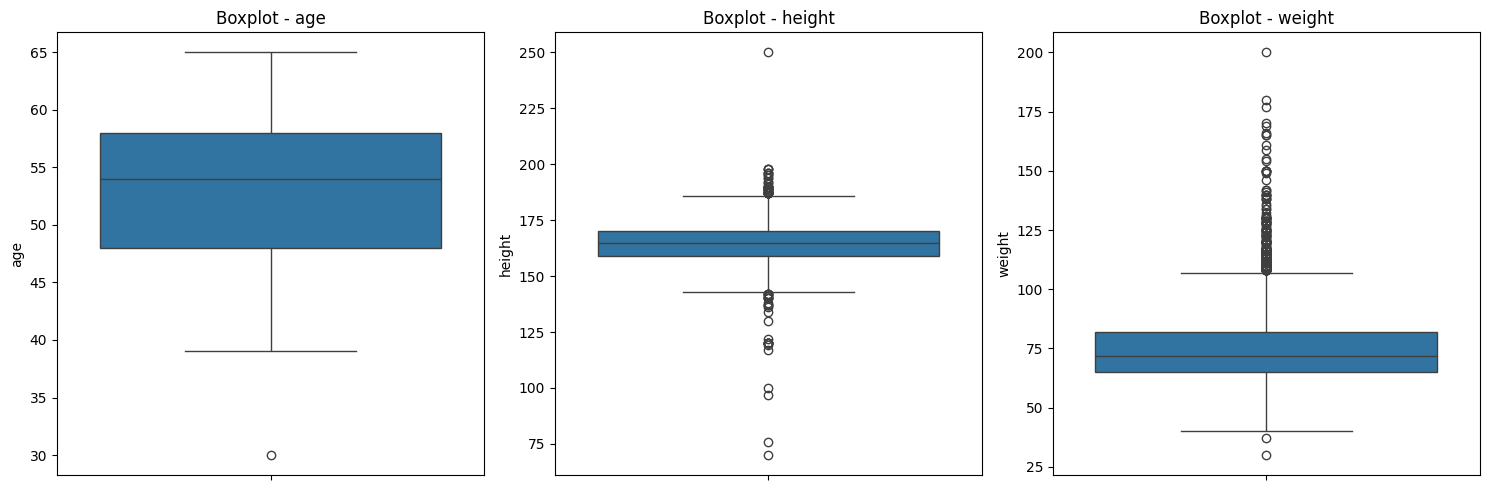

In [65]:
# Variáveis numéricas
colunas = ['age', 'height', 'weight']

fig, axes = plt.subplots(1,3,figsize=(15, 5))

for ax, coluna in zip(axes.flatten(), colunas):
    sns.boxplot(y=base[coluna], ax=ax)
    ax.set_title(f'Boxplot - {coluna}')
    ax.set_xlabel('')
    ax.set_ylabel(coluna)

plt.tight_layout()
plt.show()

Height e weight apresentam muitos outliers mesmo depois da padronização o que pode ser um indicativo da variedade dos perfis doss 
pacientes dentro do estudo. Uma maior presença de características diversas nos grupos pode ser bom para apontar tendências atingindo perfis que poderiam estar fora do grupo. Por isso, os dados não serão retirados.

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


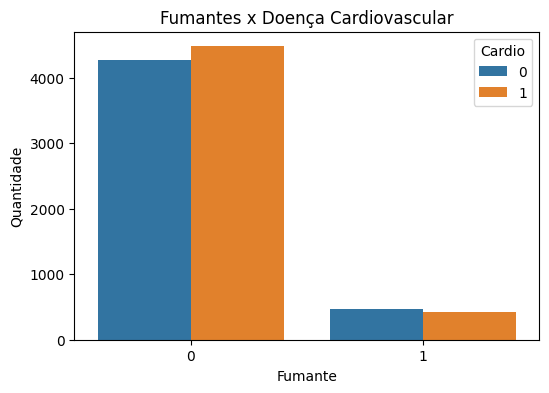

In [71]:
plt.figure(figsize=(6,4))
sns.countplot(x='smoke', hue='cardio_disease', data=base)

plt.title('Fumantes x Doença Cardiovascular')
plt.xlabel('Fumante')
plt.ylabel('Quantidade')
plt.legend(title='Cardio')
plt.show()

A maior parte das pessoas que possui doença cardiovascular não é fumante, o que pode indicar que o fumo não tem grande influência nessa ocorrência.

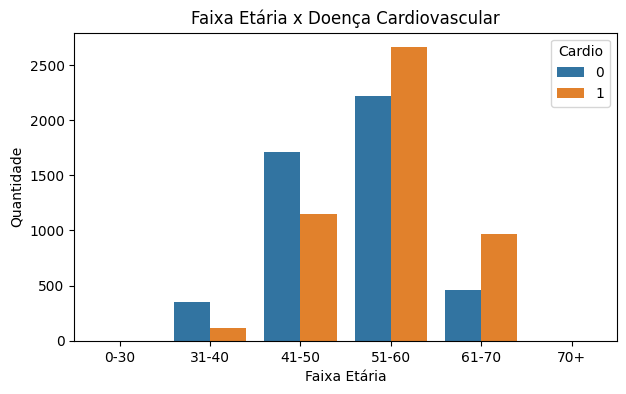

In [56]:
base['faixa_idade'] = pd.cut(base['age'],
                             bins=[0, 30, 40, 50, 60, 70, 100],
                             labels=['0-30', '31-40', '41-50', '51-60', '61-70', '70+'])

plt.figure(figsize=(7,4))
sns.countplot(x='faixa_idade', hue='cardio_disease', data=base)

plt.title('Faixa Etária x Doença Cardiovascular')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade')
plt.legend(title='Cardio')
plt.show()

A faixa entre 41-70 reune a maior quantidade de indivíduos que apresentam doenças cardiovasculares, com a maior parte deles na faixa de 51-60 anos de idad,tornando essa faixa um possível fator de risco.

In [67]:
base['weight'].dtype

dtype('float64')

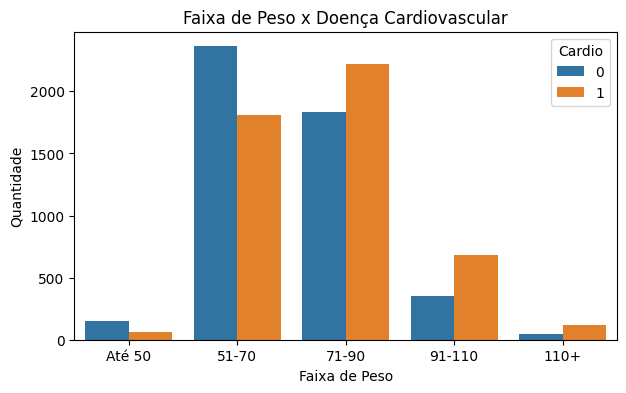

In [69]:
base['faixa_peso'] = pd.cut(base['weight'],
                            bins=[0, 50, 70, 90, 110, 150],
                            labels=['Até 50', '51-70', '71-90', '91-110', '110+'])

plt.figure(figsize=(7,4))
sns.countplot(x='faixa_peso', hue='cardio_disease', data=base)

plt.title('Faixa de Peso x Doença Cardiovascular')
plt.xlabel('Faixa de Peso')
plt.ylabel('Quantidade')
plt.legend(title='Cardio')
plt.show()

A faixa entre 51-90 quilos reune a maior quantidade de indivíduos que apresentam doenças cardiovasculares, com a maior parte deles na faixa de 71-90 quilos,tornando essa faixa um possível fator de risco.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



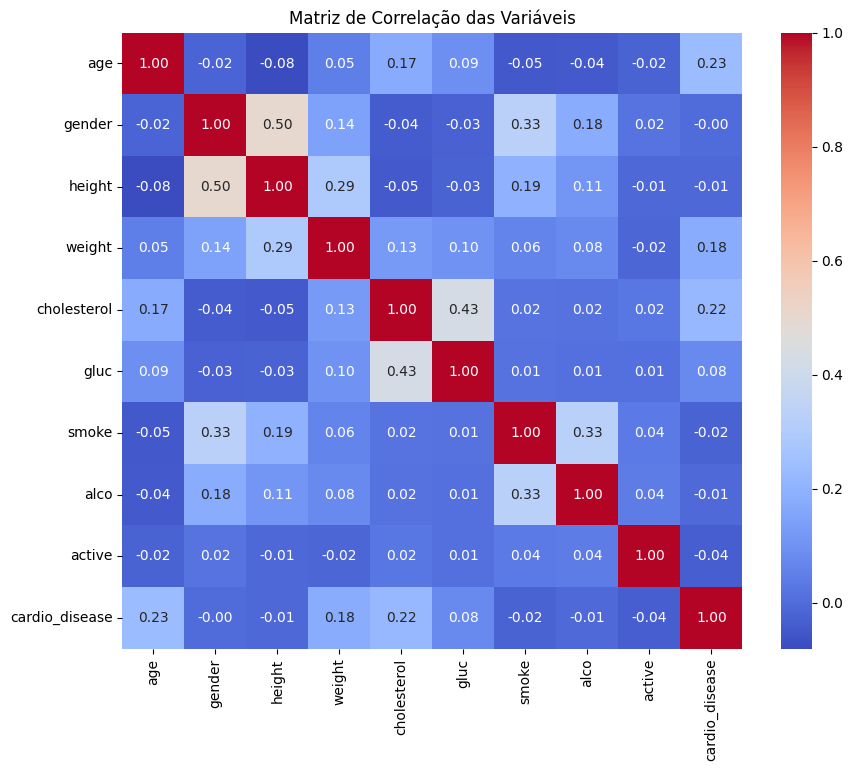

In [70]:

# Selecionar apenas variáveis numéricas
corr = base.select_dtypes(include=['int64', 'float64']).corr()

# Visualizar matriz
plt.figure(figsize=(10,8))
sns.heatmap(corr, 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')

plt.title('Matriz de Correlação das Variáveis')
plt.show()

As variáveis gênero, altura, fumo, ingestão de álcool e prática de atividade apresentam correlação baixa(próxima a zero) com a variável alvo do estudo que é a presença de doença cardiovascular. Já idade, colesterol e peso apresentam correlação positiva fraca com a variável de interesse(doença cardiovascular). Entretanto, algumas outras variáveis apresentam forte correlação positiva: gênero e altura(0.5) indica diferença de altura enre os 2 grupos de gênero, colesterol e glicose(0.43) indica que indivíduos com maiores níveis de glicose tendem a apresentar colesterol mais alto, fumo e genero(0.33) assim como fumo e tabaco(0.33) sugere que o hábito de fma se manifesta em proporções diferentes dependendo do gênero.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa. Sim, porque e idade, peso e altura por apresentarem valores muito distantes podem distorcer a análise fazendo com que o algoritmo dê mais importância a uma variável do que a outra.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento. 


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [79]:
X = base.drop('cardio_disease', axis=1)

X = X.drop(['faixa_idade', 'faixa_peso'], axis=1)

Y = base['cardio_disease']

In [81]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state =42)

In [82]:
X = base.drop('cardio_disease', axis = 1) 
Y = base['cardio_disease']
base['cardio_disease'].value_counts()

cardio_disease
1    4900
0    4740
Name: count, dtype: int64

In [85]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [86]:
print("X:")
print(X.shape)

print("\nY:")
print(Y.shape)

X:
(9640, 11)

Y:
(9640,)


# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [87]:
modelo = LogisticRegression(random_state=42)
modelo.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [88]:
modelo.intercept_

array([0.06536296])

In [89]:
modelo.coef_

array([[ 0.4301015 ,  0.02798733, -0.07869899,  0.37827734,  0.41895378,
        -0.08910905, -0.05752097,  0.0115515 , -0.08314276]])

In [91]:
previsoes = modelo.predict(X_train)
relatorio = classification_report(Y_train, previsoes)
print('Relatório')
print(relatorio)


Relatório
              precision    recall  f1-score   support

           0       0.63      0.64      0.63      3767
           1       0.65      0.64      0.64      3945

    accuracy                           0.64      7712
   macro avg       0.64      0.64      0.64      7712
weighted avg       0.64      0.64      0.64      7712



# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [94]:
Y_pred_test = modelo.predict(X_test)
relatorio = classification_report(Y_test, Y_pred_test)
print('Relatório ')
print (relatorio)

Relatório 
              precision    recall  f1-score   support

           0       0.64      0.65      0.65       973
           1       0.64      0.62      0.63       955

    accuracy                           0.64      1928
   macro avg       0.64      0.64      0.64      1928
weighted avg       0.64      0.64      0.64      1928



AUC:0.64


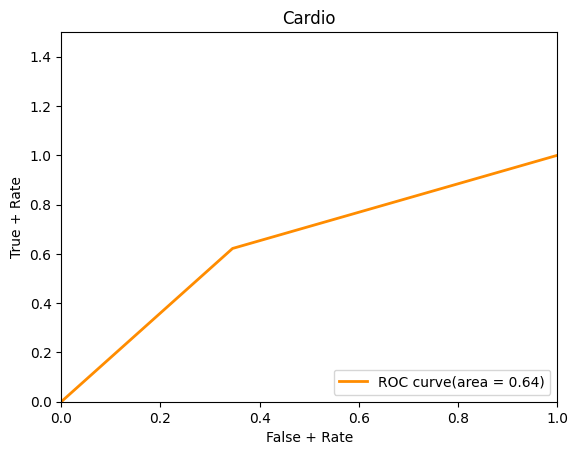

In [100]:
fpr,tpr,thresholds = roc_curve(Y_test, Y_pred_test)
roc_auc = roc_auc_score(Y_test, Y_pred_test)
print('AUC:{:.2f}'.format(roc_auc))
plt.figure()
plt.plot(fpr, tpr, color = 'darkorange', lw = 2, label =('ROC curve(area = %0.2f)'% roc_auc))
plt.plot([0.1], [0.1], color = 'navy', lw = 2, linestyle = ('--'))
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.5])
plt.xlabel('False + Rate')
plt.ylabel('True + Rate')
plt.title('Cardio')
plt.legend(loc ='lower right')
plt.show()


# 7) Explique:

A) Explique com suas palavras regressão logistica:
é ferramenta para problemas de classificação binária em aprendizado supervisionado. É usada para prever uma categoria, ela calcula a probabilidade de um evento acontecer entre 0 e 1. Em seguida, classifica o resultado como 1 caso > 0.5. Isso graças a função sigmóide que converte as variáveis em probabilidades entre 0 e 1. 

B) Explique porque a regressão logistica é um modelo de classificação. Porque o que se busca como retorno não é um número (valor contínuo) é a qual a categoria pertence a variável alvo, o objetivo é justamente classificar-categorizar.


C) Explique quais pontos em comum a regressão logistica9usa função sigmóide) tem da regressão linear(usa diretamente a reta).
A principal diferença está na saída dos resultados e no objetivo já que ambas estão dentro do que se considera aprendizado supervisionado, utilizam a equação da reta,calculam os coeficientes e buscam explorar as relações entre as variáveis. Enquanto na regressão logística o que se espera é uma classificação como já exposto no item A na linear o que se busca é o oposto, o valor contínuo(uma temperatura, um preço ...)
